In [1]:
import os
import numpy as np
import cv2
from random import shuffle
from tqdm import tqdm  
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau , ModelCheckpoint
from collections import Counter
from os import path
from tensorflow import keras
from tensorflow.keras.models import load_model

In [2]:

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, classifier_layer_names): 
     #1,creation dun petite model qui prend les input de not model est dernier layers 
     last_convLayer = model.get_layer(last_conv_layer_name)
     last_layerModel = keras.Model(model.inputs, last_convLayer.output)
    #2, creation autre model qui prend la decision ex(covid19)
     classifier_input = keras.Input(shape=last_convLayer.output.shape[1:])
     x = classifier_input
     for layer_name in classifier_layer_names:
            x = model.get_layer(layer_name)(x)
     classifier_model = keras.Model(classifier_input, x)
     with tf.GradientTape() as tape:
            # entrer image dans le model last_conv_layer_model et observer output pour calculer les derivers
            lastConv_layerOutput = last_layerModel(img_array)
            tape.watch(lastConv_layerOutput)
            preds = classifier_model(lastConv_layerOutput)
            #prend le grand probabilte
            topIndex = tf.argmax(preds[0])
            top_class_channel = preds[:, topIndex]
        #calculer le deriver de output
     grads = tape.gradient(top_class_channel, lastConv_layerOutput)
     Moyen_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        #transformer les output to array pour faciliter le calcule et for(map*wieght)
     lastConv_layerOutput = lastConv_layerOutput.numpy()[0]
     Moyen_grads = Moyen_grads.numpy()
     for i in range(Moyen_grads.shape[-1]):
            lastConv_layerOutput[:, :, i] *= Moyen_grads[i]
        # fusioner tout les output
     heatmap = np.mean(lastConv_layerOutput, axis=-1)
     heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
     return heatmap, topIndex.numpy()

In [3]:

def superimposed_img(image, heatmap):
    # Rescaling  heatmap en (0-255)
    heatmap = np.uint8(255 * heatmap)
    # donner les couleurs jet (0-255) a couleur 
    jet = cm.get_cmap("jet")
    #donner les couleurs de les 3 premiers couleur RGB
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    #creation image en les couleur rgb
    jet_heatmap = keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((224, 224))
    jet_heatmap = keras.preprocessing.image.img_to_array(jet_heatmap)
    #visualisation de les image (0.4 = pour regarder heatmap et image originale)
    superimposed_img = jet_heatmap * 0.4 + image
    superimposed_img = keras.preprocessing.image.array_to_img(superimposed_img)
    return superimposed_img

In [4]:
def categorical_smooth_loss(y_true, y_pred, label_smoothing=0.1):
    loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred, label_smoothing=label_smoothing)
    return loss


In [5]:
model_path = r"D:\BTS\2DAI\PFE\Projects\PFE__Model\PFE___FVM"
model_vgg_load = load_model(path.join(model_path,'X-rays_best_model.h5'))

model_vgg_load.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_188 (Conv2D)            (None, 111, 111, 32  864         ['input_3[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_188 (Batch  (None, 111, 111, 32  96         ['conv2d_188[0][0]']             
 Normalization)                 )                                                           

In [6]:
#loading data
Data_path = r"D:\BTS\2DAI\PFE\Projects\PFE__Model"
X_test = np.load(path.join(Data_path, 'testX.npy'))
Y_test = np.load(path.join(Data_path, 'testY.npy'))



In [7]:
sample_data=X_test
labels=['COVID19', 'NORMAL', 'PNEUMONIA']
sample_label=Y_test


In [8]:

out_put = model_vgg_load.predict(np.expand_dims(sample_data[0], axis=0))

1/1 [==============================] - 3s 3s/step


In [9]:
labels[np.argmax(out_put)]

'COVID19'

In [10]:
sample_label[0]

array([1, 0, 0])

In [11]:

last_conv_layer_name = "mixed10"
classifier_layer_names = [
    "global_average_pooling2d_2",
    "dense_4",
    "dropout_2",
    "dense_5"
]

C:\Users\MSI\AppData\Local\Temp\ipykernel_13088\2709454777.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


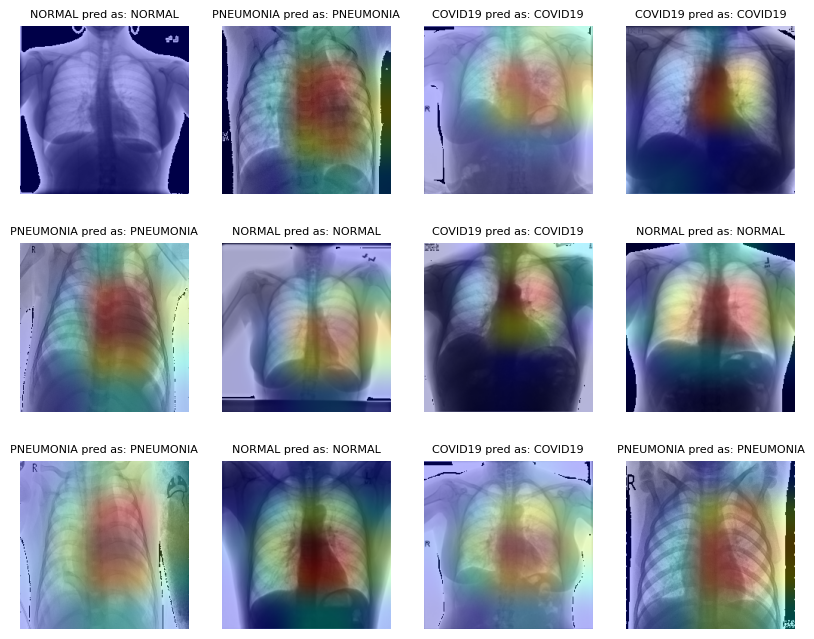

In [12]:

plt.figure(figsize=(10,8))
k=2
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.axis('off')
    heatmap, top_index = make_gradcam_heatmap(np.expand_dims(sample_data[k], axis=0), model_vgg_load, last_conv_layer_name, classifier_layer_names)
    img = np.uint8(255 * sample_data[k])
    s_img= superimposed_img(img, heatmap)
    plt.imshow(s_img)
    plt.title(labels[np.argmax(sample_label[k])] + " pred as: " + labels[top_index], fontsize=8)
    k=k+1
    